In [1]:
# import packages
import pandas as pd
import numpy as np
from typing import Tuple

from sklearn.metrics import mean_squared_error

import pymc as pm
import pymc.sampling.jax as pmjax
import pytensor.tensor as pt
import xarray as xr
import arviz as az
import arviz_plots as azp

import matplotlib.pyplot as plt
RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.1
numpy: 2.4.3
pymc: 6.2.0
pytensor: 3.2.3
arviz: 1.2.0
arviz_plots: 1.2.0


In [2]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs)-> xr.DataTree:
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pmjax.sample_numpyro_nuts(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        xr.DataTree.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling

    Returns:
        xr.DataTree: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [3]:
# first use handy index function
def define_index(data: pd.DataFrame, label: str) -> Tuple[np.array, dict]:
    """Defines an index variable starting at 0.
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values.astype("int32")
    return index_vals, lookup

def map_index(data: pd.DataFrame, label: str, lookup_dict: dict) -> np.array:
    """Applies an index to new values
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format
        lookup_dict (dict): dictionary that contains the mappings from inputs to index

    Returns:
        np.array: indexed values
    """
    s = data[label].astype(str)
    vals = s.map(lookup_dict).values
    return vals

In [4]:
# import data
df = pd.read_csv('data/bat_speed_model_data_monthly.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,ev90,latent_ev90_mean,latent_ev90_std,swing_total,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,is_imputed,is_complete
0,120074,2016,Mar/Apr,0,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,107.51,106.917612,0.667010,168.0,NaN,73.465416,1.504693,73.465416,1,0
1,120074,2016,May,1,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,108.94,106.956475,0.629350,193.0,NaN,73.512082,1.493523,73.512082,1,0
2,120074,2016,Jun,2,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,105.84,106.909794,0.609482,176.0,NaN,73.470723,1.487282,73.470723,1,0
3,120074,2016,Jul,3,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,106.45,106.908630,0.615410,181.0,NaN,73.469541,1.489754,73.469541,1,0
4,120074,2016,Aug,4,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,107.94,106.924354,0.632130,180.0,NaN,73.484835,1.504493,73.484835,1,0


In [5]:
# test data will be all of 2025 to present
train_df = df.loc[df['year']<2025].reset_index(drop=True)
test_df = df.loc[df['year']>=2025].reset_index(drop=True)
print(train_df.shape[0])
print(test_df.shape[0])

seen_players = set(train_df["player_full_id"])
test_df["seen_player"] = test_df["player_full_id"].isin(seen_players)
test_seen = test_df.loc[test_df["seen_player"]].copy()
test_unseen = test_df.loc[~test_df["seen_player"]].copy()
print(test_seen["player_full_id"].unique().shape[0])
print(test_unseen["player_full_id"].unique().shape[0])

23793
5169
580
190


In [6]:
# standardize age
age_mean = np.mean(train_df['age'])
age_std = np.std(train_df['age'])
train_df['age_z'] = (train_df['age'] - age_mean)/age_std
test_df['age_z'] = (test_df['age'] - age_mean)/age_std

In [7]:
train_df.loc[train_df['age_z']>=3.5]['player_full_id'].unique()

<ArrowStringArray>
['Ichiro Suzuki (400085)', 'Albert Pujols (405395)', 'Nelson Cruz (443558)']
Length: 3, dtype: str

In [8]:
n_obs = len(train_df)
train_df["player_idx"], player_lookup = define_index(train_df, "player_full_id")
player_idx_vals = train_df['player_idx'].values.astype("int32")
player_name_list = list(player_lookup.keys())

train_df['month_idx'], month_lookup = define_index(train_df, 'month_name')
month_idx_vals = train_df['month_idx'].values.astype("int32")
month_name_list = list(month_lookup.keys())

train_df['season_idx'], season_lookup = define_index(train_df, 'year')
season_idx_vals = train_df['season_idx'].values.astype("int32")
season_list = list(season_lookup.keys())

train_df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,bat_speed,imputed_bat_speed,imputed_bat_speed_std,model_bat_speed,is_imputed,is_complete,age_z,player_idx,month_idx,season_idx
0,120074,2016,Mar/Apr,0,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,NaN,73.465416,1.504693,73.465416,1,0,3.195013,0,0,0
1,120074,2016,May,1,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,NaN,73.512082,1.493523,73.512082,1,0,3.217249,0,1,0
2,120074,2016,Jun,2,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,NaN,73.470723,1.487282,73.470723,1,0,3.240227,0,2,0
3,120074,2016,Jul,3,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,NaN,73.469541,1.489754,73.469541,1,0,3.262463,0,3,0
4,120074,2016,Aug,4,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,NaN,73.484835,1.504493,73.484835,1,0,3.285441,0,4,0


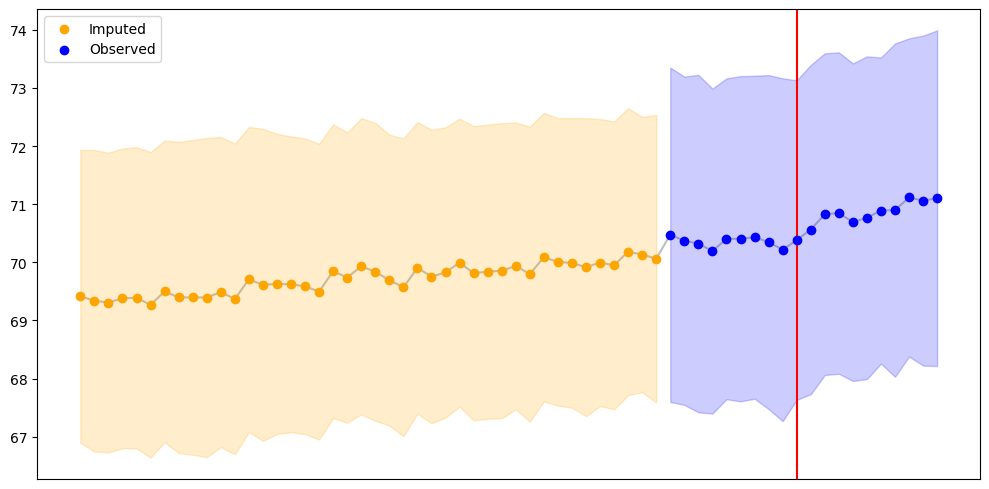

In [14]:
grp = df.groupby(["year","month_name"]).agg(
    mean=("model_bat_speed", "mean"),
    std=("model_bat_speed", "std"),
    count=("model_bat_speed", "count"),
    is_imputed=("is_imputed", "min")
    ).reset_index()
grp["month_name"] = pd.Categorical(grp["month_name"], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
grp_sorted = grp.sort_values(["year","month_name"]).reset_index(drop=True)
grp_sorted["x"] = grp_sorted["year"].astype(str) + "-" + grp_sorted["month_name"].astype(str)
obs_mask = grp_sorted["is_imputed"] == 0
imp_mask = ~obs_mask

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(grp_sorted["x"], grp_sorted["mean"], color="gray", alpha=0.5, zorder=1)
ax.scatter(grp_sorted.loc[imp_mask, "x"], grp_sorted.loc[imp_mask, "mean"], color="orange", label="Imputed", zorder=3)
ax.scatter(grp_sorted.loc[obs_mask, "x"], grp_sorted.loc[obs_mask, "mean"], color="blue", label="Observed", zorder=3)
ax.fill_between(range(len(grp_sorted)), grp_sorted["mean"] - grp_sorted["std"], grp_sorted["mean"] + grp_sorted["std"], where=imp_mask, color="orange", alpha=0.2)
ax.fill_between(range(len(grp_sorted)), grp_sorted["mean"] - grp_sorted["std"], grp_sorted["mean"] + grp_sorted["std"], where=obs_mask, color="blue", alpha=0.2)
ax.axvline(x=grp_sorted[grp_sorted["year"]==2025].index.min(), color="red")
ax.set_xticks([])
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [15]:
time_idx_mean = train_df["time_index"].mean()
train_df["time_idx_c"] = train_df["time_index"] - time_idx_mean
test_df["time_idx_c"] = test_df["time_index"] - time_idx_mean

slope, intercept = np.polyfit(train_df["age_z"], train_df["time_idx_c"], 1)
train_df["time_idx_resid"] = train_df["time_idx_c"] - (slope * train_df["age_z"] + intercept)
test_df["time_idx_resid"] = test_df["time_idx_c"] - (slope * test_df["age_z"] + intercept)
print(slope)
print(intercept)

time_values = train_df["time_idx_resid"].values

is_imputed_data_vals = train_df['is_imputed'].values

-0.3455361065003094
-3.2874113530027088e-15


In [16]:
bat_speed_target = train_df['model_bat_speed'].values
swings_sqrt_values = np.sqrt(train_df['swing_total'].values)

# define emprical prior for bat speed
prior_mean = np.mean(bat_speed_target)
prior_std = np.std(bat_speed_target)
print(prior_mean)
print(prior_std)

# define age and age squared for the quadratic model
age_values = train_df['age_z'].values
age_sq_values = age_values**2

69.82902866298696
2.6253627779641837


<Axes: >

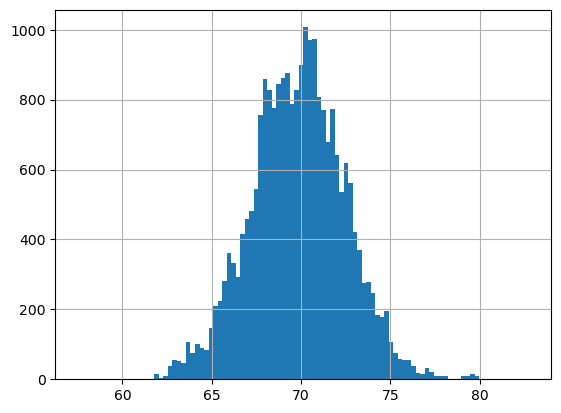

In [17]:
train_df['model_bat_speed'].hist(bins=100)

In [18]:
print(prior_mean+prior_std*1.25*3)
print(prior_mean-prior_std*1.25*3)

assert(np.isnan(swings_sqrt_values).sum() == 0)

79.67413908035265
59.98391824562127


In [38]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
}

# pymc model
with pm.Model(coords=coords) as model_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_values, dims=("observation_id",))
    age_sq_data = pm.Data('age_sq_data', age_sq_values, dims=("observation_id",))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)

    # player random
    sigma_player = pm.Exponential("sigma_player", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_player, dims=("player",))

    # age
    a = pm.Normal("a", mu=-0.13, sigma=0.025)
    b = pm.Normal("b", mu=0, sigma=0.025)
    f = pm.Deterministic('f', a*age_sq_data + b*age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    # likelihood
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma_ratio = pm.LogNormal("sigma_ratio", 0, 0.5)
    sigma = pm.Deterministic('sigma', sigma_observed * pm.math.switch(is_imputed_data, sigma_ratio, 1.0))
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [39]:
# sample
trace_quad = sample(model_quad, draws = 2000, tune = 2000, target_accept = 0.99,  path='quad_model.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [41]:
az.summary(trace_quad, var_names=['mu_pop', 'sigma_player', 'a', 'b', 'sigma_observed', 'sigma_ratio'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_pop,69.42,0.02,69.39,69.45,399.13,723.74,1.02,0.0,0.0
sigma_player,2.47,0.05,2.39,2.57,9606.12,5749.98,1.00,0.0,0.0
a,-0.13,0.00,-0.13,-0.12,3117.55,4531.29,1.00,0.0,0.0
b,0.03,0.01,0.01,0.04,2071.21,2983.21,1.00,0.0,0.0
sigma_observed,14.13,0.15,13.83,14.44,4922.38,5404.19,1.00,0.0,0.0
sigma_ratio,0.34,0.00,0.33,0.35,4826.73,5559.66,1.00,0.0,0.0


In [42]:
az.summary(trace_quad, var_names=['mu_player'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[David Ortiz (120074)],5.29,0.15,4.99,5.59,7676.10,5829.02,1.00,0.00,0.00
mu_player[Alex Rodriguez (121347)],3.51,0.23,3.06,3.95,10076.02,6060.62,1.00,0.00,0.00
mu_player[Adrian Beltré (134181)],0.81,0.10,0.62,1.01,6915.38,5732.08,1.00,0.00,0.00
mu_player[Carlos Beltrán (136860)],1.85,0.12,1.62,2.07,7159.35,5624.01,1.00,0.00,0.00
mu_player[Jayson Werth (150029)],2.81,0.13,2.56,3.05,9425.15,6172.99,1.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...
mu_player[Jackson Holliday (702616)],1.63,0.71,0.22,3.07,10741.61,6434.61,1.00,0.01,0.01
mu_player[Nacho Alvarez Jr. (805373)],-0.54,1.53,-3.55,2.47,10975.49,5681.29,1.00,0.01,0.01
mu_player[Jacob Wilson (805779)],-5.12,1.02,-7.17,-3.09,10466.18,6551.25,1.00,0.01,0.01
mu_player[Masataka Yoshida (807799)],1.29,0.20,0.91,1.68,10322.03,6027.08,1.00,0.00,0.00


In [ ]:
summary = az.summary(trace_quad, round_to=3)
summary.loc[summary["r_hat"] > 1.01, ["mean", "sd", "ess_bulk", "ess_tail", "r_hat"]].sort_values("r_hat", ascending=False)

,mean,sd,ess_bulk,ess_tail,r_hat
mu_player[Jung Hoo Lee (808982)],0.089,0.947,166.995,339.610,1.037
mu_pop,69.417,0.016,430.815,740.637,1.015


In [27]:
def plot_aging_curve(trace, age_z, model_name="Model"):
    f_draws = trace.posterior["f"].values
    mu_pop_draws = trace.posterior["mu_pop"].values
    f = f_draws.reshape(-1, f_draws.shape[-1])
    mu_pop = mu_pop_draws.reshape(-1, 1)

    curves = mu_pop + f
    sort_idx = np.argsort(age_z)
    age_sorted = age_z[sort_idx]
    curves_sorted = curves[:, sort_idx]

    _, ax = plt.subplots(figsize=(8, 6))
    rng = np.random.default_rng(RANDOM_SEED)
    subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
    for idx in subset_indices:
        ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

    ax.set_title(f"{model_name} Aging Curve")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Bat Speed (mph)")
    ax.set_ylim(65, 75)
    ax.grid(True)
    plt.show()
    return curves_sorted

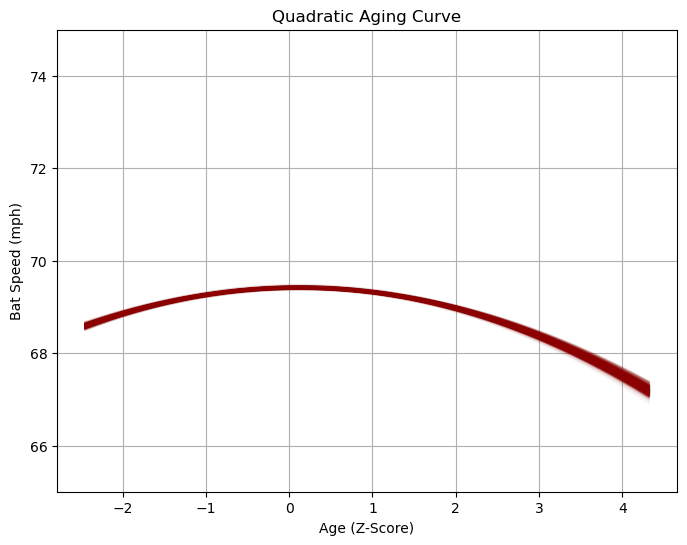

In [28]:
quad_aging_curve = plot_aging_curve(trace_quad, age_values, model_name="Quadratic")

In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "month": month_name_list,
    "player": player_name_list,
    "season": season_list,
}

# pymc model
with pm.Model(coords=coords) as model_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    month_idx = pm.Data("month_idx", month_idx_vals, dims=("observation_id",))
    season_idx = pm.Data("season_idx", season_idx_vals, dims=("observation_id",))
    time_data = pm.Data("time_data", time_values, dims=("observation_id",))
    age_data = pm.Data('age_data', age_values, dims=("observation_id",))
    age_sq_data = pm.Data('age_sq_data', age_sq_values, dims=("observation_id",))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)

    # player random
    sigma_player = pm.Exponential("sigma_player", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_player, dims=("player",))

    # sigma_drift = pm.HalfNormal("sigma_drift", sigma=0.1)
    # player_drift_raw = pm.GaussianRandomWalk("player_drift_raw", sigma=sigma_drift, dims=("player","season"))
    # player_drift = pm.Deterministic("player_drift", player_drift_raw - player_drift_raw.mean(axis=0, keepdims=True), dims=("player", "season"))

    # linear component
    year_weight = pm.Normal("year_weight", 0, 1)

    # month index
    sigma_month = pm.Exponential("sigma_month", 1.0)
    month_effect = pm.ZeroSumNormal("month_effect", sigma_month, dims=("month"))

    # age
    a = pm.Normal("a", mu=0, sigma=1)
    b = pm.Normal("b", mu=-0.14, sigma=0.04)
    f = pm.Deterministic('f', a*age_sq_data + b*age_data)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f + month_effect[month_idx] + year_weight*time_data
    # likelihood
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma_row = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma_row/swings_sqrt, observed=target_data, dims=("observation_id",))

In [16]:
spp = sample_posterior_pred(model_quad, trace_quad)

Sampling: [target]


Output()

In [ ]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.set_xlabel("Bat Speed (mph)")

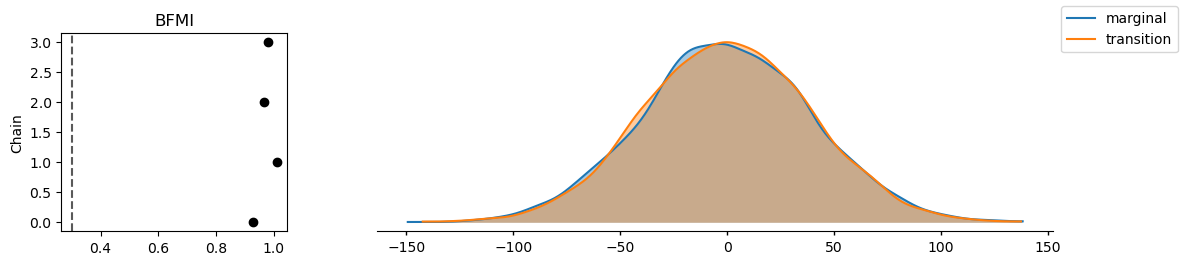

In [24]:
az.plot_energy(trace_quad)

In [91]:
def make_preds(model, trace, df, player_lookup):
    with model:
        pm.set_data({
            "player_idx": df["player_idx"].values.astype("int32"),
            "age_data": df["age_z"].values,
            "age_sq_data": df["age_z"].values**2,
            "swings_sqrt": np.sqrt(df["swing_total"].values),
            "time_data": df["time_idx_resid"].values,
            "month_idx": df["month_idx"].values.astype("int32"),
            "target_data": np.zeros(len(df)),
            "is_imputed_data": np.zeros(len(df), dtype="int32")
        },
        coords = {
            "observation_id": np.arange(len(df)),
            "player": list(player_lookup.keys())
        }
        )
        spp = pm.sample_posterior_predictive(
            trace,
            var_names=["target"],
            predictions=True,
            random_seed=RANDOM_SEED,
            return_inferencedata=False
        )
    return spp


def make_preds_quadratic(model, trace, df, player_lookup, month_lookup):
    df = df.reset_index(drop=True)
    df['player_idx'] = map_index(df, "player_full_id", player_lookup)
    df['month_idx'] = map_index(df, "month_name", month_lookup)
    seen = df['player_idx'].notna().values

    n_obs = len(df)
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    preds = np.empty((n_samples, n_obs))

    if seen.any():
        seen_df = df[seen]
        spp = make_preds(model, trace, seen_df, player_lookup)
        target_arr = spp["target"]
        n_chains, n_draws = target_arr.shape[0], target_arr.shape[1]
        preds[:, seen] = target_arr.reshape(n_chains * n_draws, -1)

    if (~seen).any():
        unseen_df = df[~seen]
        age = unseen_df["age_z"].values
        age_sq = age ** 2
        swings_sqrt = np.sqrt(unseen_df["swing_total"].values)
        time_idx = unseen_df["time_idx_resid"].values
        month_idx = unseen_df["month_idx"].values.astype(int)

        mu_pop = post["mu_pop"].values.reshape(-1)
        sigma_player = post["sigma_player"].values.reshape(-1)
        a = post["a"].values.reshape(-1)
        b = post["b"].values.reshape(-1)
        year_weight = post["year_weight"].values.reshape(-1)
        month_effect = post["month_effect"].values.reshape(n_samples, -1)
        sigma_observed = post["sigma_observed"].values.reshape(-1)

        n_unseen = (~seen).sum()
        rng = np.random.default_rng(RANDOM_SEED)
        mu_player_new = rng.normal(0.0, sigma_player[:, None], size=(n_samples, n_unseen))

        f = a[:, None] * age_sq[None, :] + b[:, None] * age[None, :]
        trend = year_weight[:, None] * time_idx[None, :]
        month_term = month_effect[:, month_idx]

        theta = mu_pop[:, None] + mu_player_new + f + trend + month_term
        preds[:, ~seen] = rng.normal(theta, sigma_observed[:, None] / swings_sqrt[None, :])

    return preds, seen

In [27]:
def validate_preds(preds, seen, df):
    y = df['model_bat_speed'].values
    seen = np.asarray(seen, dtype=bool)
    def score_output(mask):
        y_i = y[mask]
        p_i = preds[:, mask]
        pred_mean = p_i.mean(axis=0)
        lower_95, upper_95 = np.quantile(p_i, [0.025, 0.975], axis=0)

        return {
            "n": int(len(y_i)),
            "rmse": float(round(np.sqrt(mean_squared_error(y_i, pred_mean)), 4)),
            "coverage_95": float(round(np.mean((y_i >= lower_95) & (y_i <= upper_95)), 4)),
        }

    return {
        "overall": score_output(np.ones(len(y), dtype=bool)),
        "seen": score_output(seen) if seen.any() else None,
        "unseen": score_output(~seen) if (~seen).any() else None,
    }

In [92]:
quad_preds, seen = make_preds_quadratic(model_quad, trace_quad, train_df, player_lookup, month_lookup)
validate_preds(quad_preds, seen, train_df)

Sampling: [target]


Output()

{'overall': {'n': 23793, 'rmse': 0.7819, 'coverage_95': 0.989},
 'seen': {'n': 23793, 'rmse': 0.7819, 'coverage_95': 0.989},
 'unseen': None}

In [93]:
quad_preds, seen = make_preds_quadratic(model_quad, trace_quad, test_df, player_lookup, month_lookup)
validate_preds(quad_preds, seen, test_df)

Sampling: [target]


Output()

{'overall': {'n': 5169, 'rmse': 2.0752, 'coverage_95': 0.9166},
 'seen': {'n': 4330, 'rmse': 1.775, 'coverage_95': 0.9136},
 'unseen': {'n': 839, 'rmse': 3.2051, 'coverage_95': 0.9321}}

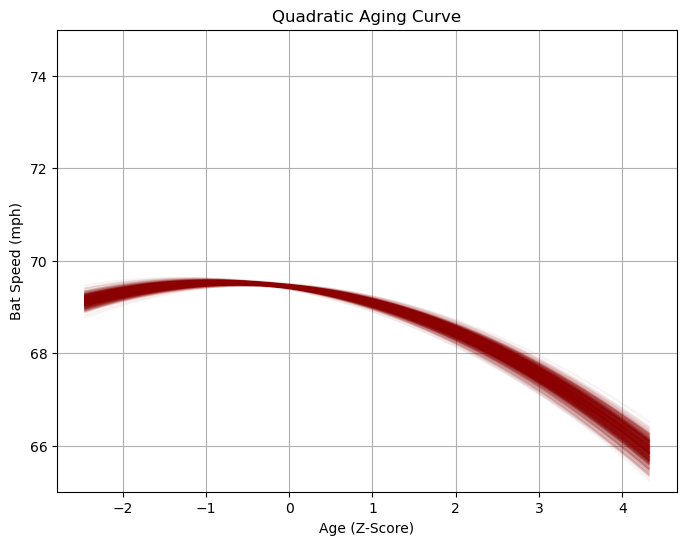

In [59]:
quad_aging_curve = plot_aging_curve(trace_quad, age_values, model_name="Quadratic")

In [84]:
a_posterior_mean = trace_quad.posterior['a'].mean(dim=("chain", "draw")).values.flatten()
b_posterior_mean = trace_quad.posterior['b'].mean(dim=("chain", "draw")).values.flatten()
a_posterior_std = trace_quad.posterior['a'].std(dim=("chain", "draw")).values.flatten()
b_posterior_std = trace_quad.posterior['b'].std(dim=("chain", "draw")).values.flatten()

age_stack_data = np.column_stack((age_sq_values, age_values))

In [ ]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_values), np.max(age_values)],
    lengthscale_range=[0.75, 1.5],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 10, c: 1.42


In [94]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list
}

with pm.Model(coords=coords) as model_gp_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_stack = pm.Data('age_stack', age_stack_data)
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))

    # hyper priors for players
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)
    sigma_player = pm.Exponential("sigma_player", 1.0)
    mu_player = pm.ZeroSumNormal("mu_player", sigma=sigma_player, dims=("player",))
    
    # mean priors
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std*1.5)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std*1.5)
    coefs = pt.stack([a, b])
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=0)
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=11, beta=11.25)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls, active_dims=[1])
    # HSGP
    gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_stack)

    # expected value
    theta = mu_pop + mu_player[player_idx] + f
    # lkhood
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=bat_speed_target, dims=("observation_id",))

In [95]:
# sample
trace_gp_quad = sample(model_gp_quad, draws = 2000, tune = 2000, target_accept = 0.99,  path='gp_expquad_quadratic.nc')

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [ ]:
az.summary(trace_gp_quad, var_names=['eta', 'ls','mu_pop', 'sigma_player', 'a','b','sigma_target','sigma','sigma_floor'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta,0.57,0.32,0.14,1.29,992.24,1708.73,1.0,0.01,0.01
ls,0.82,0.14,0.55,1.11,5700.17,5108.83,1.0,0.00,0.00
mu_pop,69.44,0.06,69.33,69.57,2259.25,2692.74,1.0,0.00,0.00
sigma_player,2.51,0.05,2.42,2.60,11825.24,6511.68,1.0,0.00,0.00
a[0],-0.14,0.01,-0.16,-0.12,9472.17,5622.09,1.0,0.00,0.00
b[0],-0.03,0.01,-0.06,-0.00,12680.86,6009.25,1.0,0.00,0.00
sigma,7.10,0.03,7.03,7.16,13794.45,6044.59,1.0,0.00,0.00


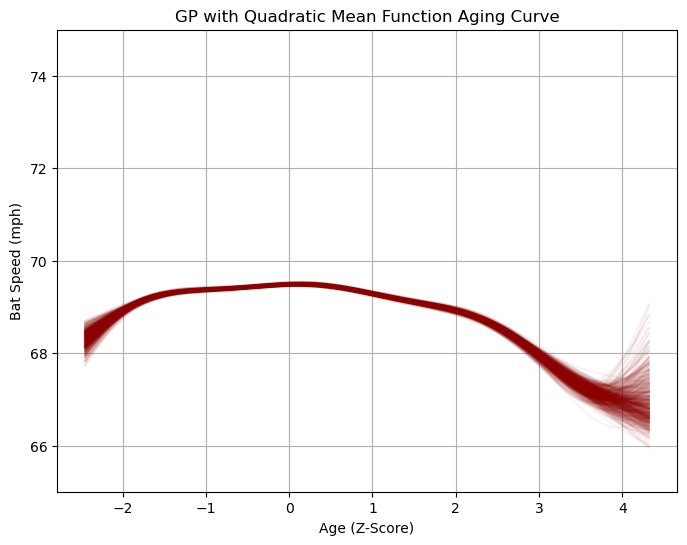

In [97]:
gp_aging_curve = plot_aging_curve(trace_gp_quad, age_values, model_name="GP with Quadratic Mean Function")

In [ ]:
def make_preds_gp_seen(model, trace, df, player_lookup):
    age_stack_data = np.column_stack((df["age_z"].values**2, df["age_z"].values))
    with model:
        pm.set_data({
            "player_idx": df["player_idx"].values.astype("int32"),
            "age_stack": age_stack_data,
            "swings_sqrt": np.sqrt(df["swing_total"].values)
        },
        coords = {
            "observation_id": np.arange(len(df)),
            "player": list(player_lookup.keys())
        }
        )
        spp = pm.sample_posterior_predictive(
            trace,
            var_names=["target"],
            predictions=True,
            random_seed=RANDOM_SEED
        )
    return spp

def make_preds_gp(model, trace, df, player_lookup):
    df = df.reset_index(drop=True)
    df['player_idx'] = map_index(df, "player_full_id", player_lookup)
    seen = df['player_idx'].notna().values

    n_obs = len(df)
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    preds = np.empty((n_samples, n_obs))

    if seen.any():
        seen_df = df[seen]
        spp = make_preds_gp_seen(model, trace, seen_df, player_lookup)
        preds[:, seen] = spp.predictions["target"].values.reshape(-1, seen.sum())

    if (~seen).any():
        unseen_df = df[~seen]
        age_stack_data = np.column_stack((unseen_df["age_z"].values ** 2, unseen_df["age_z"].values))
        swings_sqrt = np.sqrt(unseen_df["swing_total"].values)

        with model:
            pm.set_data({
                        "age_stack": age_stack_data,
                    },
            )
            f_pred = pm.sample_posterior_predictive(
                trace,
                var_names=["f"],
                predictions=True,
                random_seed=RANDOM_SEED
            )
        f_samples = f_pred.predictions["f"].values.reshape(-1, len(unseen_df))

        n_unseen = len(unseen_df)
        mu_pop = post["mu_pop"].values.reshape(-1)
        sigma_player = post["sigma_player"].values.reshape(-1)
        sigma = post["sigma"].values.reshape(-1)
        sigma_floor = post["sigma_floor"].values.reshape(-1)
        sigma_target = np.sqrt((sigma[:, None] / swings_sqrt[None, :]) ** 2 + sigma_floor[:, None] ** 2)

        rng = np.random.default_rng(RANDOM_SEED)
        mu_player_new = rng.normal(0.0, sigma_player[:, None], size=(n_samples, n_unseen))
        theta = mu_pop[:, None] + mu_player_new + f_samples
        preds[:, ~seen] = rng.normal(theta, sigma_target)

    return preds, seen

In [ ]:
gp_preds, seen = make_preds_gp(model_gp_quad, trace_gp_quad, train_df, player_lookup)
validate_preds(gp_preds, seen, train_df)

Sampling: [target]


Output()

{'overall': {'n': 23793, 'rmse': 0.742, 'coverage_95': 0.9476},
 'seen': {'n': 23793, 'rmse': 0.742, 'coverage_95': 0.9476},
 'unseen': None}

In [ ]:
gp_preds, seen = make_preds_gp(model_gp_quad, trace_gp_quad, test_df, player_lookup)
validate_preds(gp_preds, seen, test_df)

Sampling: [target]


Output()

Sampling: []


Output()

{'overall': {'n': 5169, 'rmse': 2.0568, 'coverage_95': 0.7313},
 'seen': {'n': 4330, 'rmse': 1.682, 'coverage_95': 0.7007},
 'unseen': {'n': 839, 'rmse': 3.3858, 'coverage_95': 0.8892}}

In [128]:
# add position
pdf = train_df[['bam_id','player_full_id','full','position','position_hybrid']].drop_duplicates(['player_full_id']).reset_index(drop=True)
pdf["position_idx"], position_lookup = define_index(pdf, "position")
position_idx_vals = pdf['position_idx'].values.astype("int32")
position_name_list = list(position_lookup.keys())
pdf.head()

,bam_id,player_full_id,full,position,position_hybrid,position_idx
0,120074,David Ortiz (120074),David Ortiz,DH,DH,0
1,121347,Alex Rodriguez (121347),Alex Rodriguez,SS,UTM,1
2,134181,Adrian Beltré (134181),Adrian Beltré,3B,CINF,2
3,136860,Carlos Beltrán (136860),Carlos Beltrán,CF,UTM,3
4,150029,Jayson Werth (150029),Jayson Werth,RF,COF,4


In [ ]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "position": position_name_list
}

with pm.Model(coords=coords) as model_gp_position:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_stack = pm.Data('age_stack', age_stack_data)
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    position_idx = pm.Data('position_idx', position_idx_vals, dims=('player',))

    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std*1.25)
    # position
    sigma_position = pm.Exponential("sigma_position", 1.0)
    position_effect = pm.ZeroSumNormal("position_effect", sigma=sigma_position, dims="position")
    # player
    sigma_player = pm.Exponential("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop + position_effect[position_idx], sigma=sigma_player, dims=("player",))
    
    # mean priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std*1.5)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std*1.5)
    coefs = pt.stack([a, b])
    mean = pm.gp.mean.Linear(coeffs=coefs, intercept=0)
    # covariance priors
    eta = pm.HalfNormal("eta", sigma=0.5)
    ls = pm.InverseGamma("ls", alpha=11, beta=11.25)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls, active_dims=[1])
    # HSGP
    gp = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp.prior("f", X=age_stack)
    
    # expected value
    theta = mu_player[player_idx] + f
    # lkhood
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=bat_speed_target, dims=("observation_id",))

In [130]:
# sample
trace_gp_position = sample(model_gp_position, draws = 2000, tune = 3000, target_accept = 0.99,  path='gp_expquad_quadratic_position.nc')

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [113]:
az.summary(trace_gp_position, var_names=['mu_pop','sigma_position','position_effect','sigma_player','eta','ls', 'sigma'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_pop,69.89,0.10,69.69,70.10,186.02,356.95,1.01,0.01,0.01
sigma_position,1.44,0.54,0.74,2.81,10924.09,5466.48,1.00,0.01,0.01
position_effect[DH],1.89,0.27,1.36,2.43,7882.39,6201.01,1.00,0.00,0.00
position_effect[UTM],-1.27,0.12,-1.50,-1.04,8737.48,6513.13,1.00,0.00,0.00
position_effect[CINF],0.43,0.13,0.17,0.68,10401.02,6457.25,1.00,0.00,0.00
position_effect[COF],0.07,0.13,-0.17,0.32,9307.20,6364.32,1.00,0.00,0.00
position_effect[C],-1.12,0.15,-1.41,-0.83,11483.76,6030.84,1.00,0.00,0.00
sigma_player,2.35,0.04,2.27,2.44,12547.94,6437.19,1.00,0.00,0.00
eta,0.60,0.33,0.14,1.36,234.01,348.19,1.01,0.02,0.02
ls,0.82,0.15,0.56,1.11,4728.71,5065.95,1.00,0.00,0.00


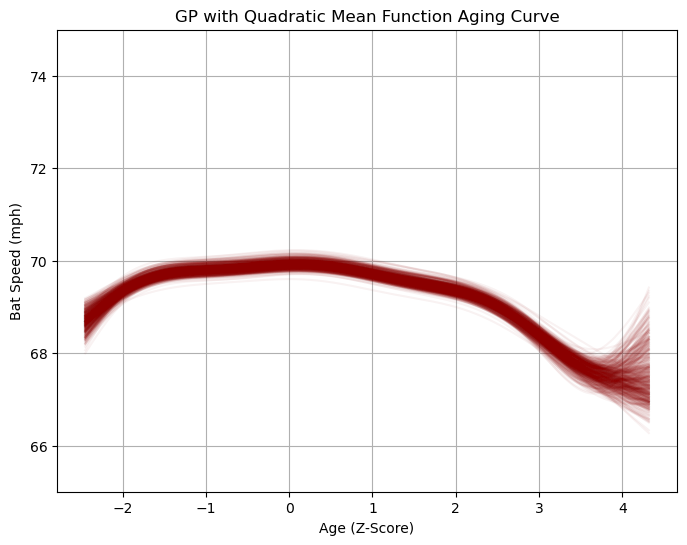

In [114]:
gp_aging_curve = plot_aging_curve(trace_gp_position, age_values, model_name="GP with Quadratic Mean Function")

In [ ]:
def make_preds_gp_seen_position(model, trace, df, player_lookup, position_lookup):
    age_stack_data = np.column_stack((df["age_z"].values**2, df["age_z"].values))
    pdf = df[['player_full_id','position_idx']].drop_duplicates(['player_full_id']).set_index('player_full_id').reindex(player_lookup.keys())
    position_idx_vals = pdf['position_idx'].values.astype("int32")

    with model:
        pm.set_data({
            "player_idx": df["player_idx"].values.astype("int32"),
            "age_stack": age_stack_data,
            "swings_sqrt": np.sqrt(df["swing_total"].values),
            'position_idx': position_idx_vals
        },
        coords = {
            "observation_id": np.arange(len(df)),
            "player": list(player_lookup.keys()),
            "position": list(position_lookup.keys())
        }
        )
        spp = pm.sample_posterior_predictive(
            trace,
            var_names=["target"],
            predictions=True,
            random_seed=RANDOM_SEED
        )
    return spp

def make_preds_gp_position(model, trace, df, player_lookup, position_lookup):
    df = df.reset_index(drop=True)
    df['player_idx'] = map_index(df, "player_full_id", player_lookup)
    df['position_idx'] = map_index(df, "position", position_lookup)
    seen = df['player_idx'].notna().values

    n_obs = len(df)
    post = trace.posterior
    n_samples = post.sizes["chain"] * post.sizes["draw"]
    preds = np.empty((n_samples, n_obs))

    if seen.any():
        seen_df = df[seen]
        spp = make_preds_gp_seen_position(model, trace, seen_df, player_lookup, position_lookup)
        preds[:, seen] = spp.predictions["target"].values.reshape(-1, seen.sum())

    if (~seen).any():
        unseen_df = df[~seen]
        age_stack_data = np.column_stack((unseen_df["age_z"].values ** 2, unseen_df["age_z"].values))
        swings_sqrt = np.sqrt(unseen_df["swing_total"].values)
        position_idx = unseen_df["position_idx"].values.astype("int32")

        with model:
            pm.set_data({
                        "age_stack": age_stack_data,
                    },
            )
            f_pred = pm.sample_posterior_predictive(
                trace,
                var_names=["f"],
                predictions=True,
                random_seed=RANDOM_SEED
            )
        f_samples = f_pred.predictions["f"].values.reshape(-1, len(unseen_df))

        n_unseen = len(unseen_df)
        mu_pop = post["mu_pop"].values.reshape(-1)
        sigma_player = post["sigma_player"].values.reshape(-1)
        sigma = post["sigma"].values.reshape(-1)
        sigma_floor = post["sigma_floor"].values.reshape(-1)
        sigma_target = np.sqrt((sigma[:, None] / swings_sqrt[None, :]) ** 2 + sigma_floor[:, None] ** 2)
        position_effect = post["position_effect"].values.reshape(n_samples, -1)
        pos_eff = position_effect[:, position_idx]

        rng = np.random.default_rng(RANDOM_SEED)
        mu_player_new = rng.normal(0.0, sigma_player[:, None], size=(n_samples, n_unseen))
        theta = mu_pop[:, None] + pos_eff + mu_player_new + f_samples
        preds[:, ~seen] = rng.normal(theta, sigma_target)

    return preds, seen

In [126]:
gp_preds, seen = make_preds_gp_position(model_gp_position, trace_gp_position, train_df, player_lookup, position_lookup)
validate_preds(gp_preds, seen, train_df)

Sampling: [target]


Output()

{'overall': {'n': 23793, 'rmse': 0.7425, 'coverage_95': 0.9478},
 'seen': {'n': 23793, 'rmse': 0.7425, 'coverage_95': 0.9478},
 'unseen': None}

In [127]:
gp_preds, seen = make_preds_gp_position(model_gp_position, trace_gp_position, test_df, player_lookup, position_lookup)
validate_preds(gp_preds, seen, test_df)

/var/folders/qh/qf8yrcwd18x8ngds01zd7cs40000gn/T/ipykernel_83321/3402578395.py:4: RuntimeWarning: invalid value encountered in cast
  position_idx_vals = pdf['position_idx'].values.astype("int32")
/var/folders/qh/qf8yrcwd18x8ngds01zd7cs40000gn/T/ipykernel_83321/3402578395.py:19: ImplicitFreezeWarning: The following trace variables were implicitly frozen, but something in their upstream suggests you may have wanted them resampled: 'mu_player' (upstream Data/coords changed (position_idx)). To resample them, pass them in `sample_vars`; to silence this warning while keeping the trace values, pass them in `freeze_vars`. Coordinates changed length ('observation_id' (23793 -> 4330)); this function is likely to fail with shape errors unless the affected variables are added to `sample_vars`.
  spp = pm.sample_posterior_predictive(
Sampling: [target]


Output()

/var/folders/qh/qf8yrcwd18x8ngds01zd7cs40000gn/T/ipykernel_83321/3402578395.py:54: ImplicitFreezeWarning: The following trace variables were implicitly frozen, but something in their upstream suggests you may have wanted them resampled: 'mu_player' (upstream Data/coords changed (position_idx)). To resample them, pass them in `sample_vars`; to silence this warning while keeping the trace values, pass them in `freeze_vars`. Coordinates changed length ('observation_id' (23793 -> 4330)); this function is likely to fail with shape errors unless the affected variables are added to `sample_vars`.
  f_pred = pm.sample_posterior_predictive(
Sampling: []


Output()

{'overall': {'n': 5169, 'rmse': 2.0582, 'coverage_95': 0.7261},
 'seen': {'n': 4330, 'rmse': 1.6816, 'coverage_95': 0.7007},
 'unseen': {'n': 839, 'rmse': 3.3916, 'coverage_95': 0.857}}